# Employee Attrition Prediction: Model Evaluation & Interpretation

### 5.1. Objective

The objective of this phase is to evaluate the candidate classification models selected during Phase 4 using the previously unseen test dataset.

The following models were selected for final evaluation based on their cross-validation performance:
- Logistic Regression
- Support Vector Machine
- Gradient Boosting

Unlike Phase 4, where model development and selection were performed using the training data and cross-validation, the test dataset will now be used to assess how well the selected models generalize to unseen employee records.

The models will be evaluated using:
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Confusion matrices
- ROC curves

Feature importance and model interpretation will also be performed to identify the variables most relevant to employee attrition.

The findings from this phase will be used to select the final model and support the business recommendations developed in Phase 6

### 5.2. Import Libraries

In [42]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.inspection import permutation_importance
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix,classification_report,roc_curve,
    ConfusionMatrixDisplay)

In [43]:
X_test = pd.read_csv("X_test_phase3.csv")

y_test = pd.read_csv("y_test_phase3.csv").squeeze()

feature_names = pd.read_csv("feature_names_phase3.csv")["Feature"].tolist()

print("Raw test features:", X_test.shape)
print("Test target:", y_test.shape)
print("Number of feature names:", len(feature_names))

Raw test features: (294, 30)
Test target: (294,)
Number of feature names: 44


In [44]:
preprocessor = joblib.load("phase3_preprocessor.pkl")

print("Preprocessor loaded successfully.")

X_test_processed = preprocessor.transform(X_test)

print("Processed test features:", X_test_processed.shape)

Preprocessor loaded successfully.
Processed test features: (294, 44)


In [45]:
selected_models = {"Logistic Regression": joblib.load("logistic_regression_phase4_model.pkl"),

    "Support Vector Machine": joblib.load("support_vector_machine_phase4_model.pkl"),

    "Gradient Boosting": joblib.load("gradient_boosting_phase4_model.pkl")}

print("Selected models loaded successfully.")

for name in selected_models:
    print("-", name)

Selected models loaded successfully.
- Logistic Regression
- Support Vector Machine
- Gradient Boosting


### 5.3. Load Selected Phase 4 Models

The three candidate models selected during Phase 4 are loaded for independent evaluation on the previously unseen test dataset.

The models were selected based on their five-fold stratified cross-validation performance on the training data.

No model is retrained using the test data. The test dataset remains strictly reserved for final evaluation.

In [46]:
print("Test features:", X_test_processed.shape)
print("Test target:", y_test.shape)

print("\nSelected models:")
for name in selected_models:
    print("-", name)

Test features: (294, 44)
Test target: (294,)

Selected models:
- Logistic Regression
- Support Vector Machine
- Gradient Boosting


### 5. 4. Generating Predictions on the Unseen Test Dataset

The selected models are now used to generate predictions on the held-out test dataset.

The test dataset contains 294 employee records that were not used during model training, cross-validation, or model selection.

For each model, both class predictions and prediction scores are generated. Class predictions are used to calculate classification metrics, while prediction scores are used for ROC-AUC and ROC curve analysis.

No model is retrained or adjusted using the test dataset.

In [47]:
test_predictions = {}
test_scores = {}

for name, model in selected_models.items():
    
    # Predicted class
    test_predictions[name] = model.predict(X_test_processed)
    
    # Prediction score/probability for ROC-AUC
    if hasattr(model, "predict_proba"):
        test_scores[name] = model.predict_proba(
            X_test_processed
        )[:, 1]
    else:
        test_scores[name] = model.decision_function(
            X_test_processed
        )

print("Test-set predictions generated successfully.")

Test-set predictions generated successfully.


### 5.5. Prediction Verification

The generated predictions are checked to confirm that each model produced one prediction for every employee in the test dataset.

In [48]:
for name in selected_models:
    print(f"{name}:")
    print("  Predictions:", test_predictions[name].shape)
    print("  Scores:", test_scores[name].shape)
    print()

Logistic Regression:
  Predictions: (294,)
  Scores: (294,)

Support Vector Machine:
  Predictions: (294,)
  Scores: (294,)

Gradient Boosting:
  Predictions: (294,)
  Scores: (294,)



### 5.6. Predicted Class Distribution

The distribution of predicted classes is examined for each model.

This check helps identify whether a model is excessively biased toward the majority class. In an employee attrition problem, a model that predicts most employees as staying may achieve relatively high Accuracy while failing to identify employees who actually leave.

Therefore, the predicted class distribution will be considered alongside Recall, Precision and F1-score.

In [49]:
for name in selected_models:
    
    print("=" * 60)
    print(name)
    print("=" * 60)
    
    counts = pd.Series(test_predictions[name]).value_counts().sort_index()
    
    percentages = (counts / len(y_test) * 100).round(2)
    
    distribution = pd.DataFrame({"Count": counts,"Percentage": percentages})
    
    distribution.index = ["Stayed (0)" if i == 0 else "Left (1)"for i in distribution.index]
    
    print(distribution)
    print()

Logistic Regression
            Count  Percentage
Stayed (0)    207       70.41
Left (1)       87       29.59

Support Vector Machine
            Count  Percentage
Stayed (0)    231       78.57
Left (1)       63       21.43

Gradient Boosting
            Count  Percentage
Stayed (0)    277       94.22
Left (1)       17        5.78



#### 5.7. Test-Set Model Performance

The selected models are evaluated on the held-out test dataset using Accuracy, Precision, Recall, F1-score and ROC-AUC. Because employee attrition is an imbalanced classification problem, the models are not evaluated based on Accuracy alone.

Recall is particularly important because it measures the proportion of employees who actually left that were correctly identified by the model. F1-score provides a balance between Precision and Recall, while ROC-AUC measures the model's ability to distinguish between employees who left and those who stayed.

These results represent the models' performance on previously unseen data and therefore provide a more reliable estimate of their generalisation ability.

In [50]:
evaluation_results = []

for name in selected_models:
    
    y_pred = test_predictions[name]
    y_score = test_scores[name]
    
    evaluation_results.append({
        "Model": name,
        "Accuracy": accuracy_score(
            y_test,
            y_pred
        ),
        "Precision": precision_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "F1-Score": f1_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_test,
            y_score
        )
    })

evaluation_df = pd.DataFrame(
    evaluation_results
)

evaluation_df.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.7551,0.3563,0.6596,0.4627,0.8035
1,Support Vector Machine,0.8163,0.4444,0.5957,0.5091,0.8054
2,Gradient Boosting,0.8503,0.5882,0.2128,0.3125,0.7941


### 5.8. Classification Reports

Classification reports provide class-level Precision, Recall and F1-score for each selected model.

Particular attention is given to the `Attrition = Yes` class because the primary business objective is to identify employees who are at risk of leaving. A model with high overall Accuracy but poor Recall for the attrition class may fail to identify a substantial proportion of employees who actually leave.

In [51]:
for name in selected_models:
    
    print("=" * 70)
    print(name)
    print("=" * 70)
    
    print(classification_report(y_test,test_predictions[name],target_names=["Stayed", "Left"],digits=4,zero_division=0))

Logistic Regression
              precision    recall  f1-score   support

      Stayed     0.9227    0.7733    0.8414       247
        Left     0.3563    0.6596    0.4627        47

    accuracy                         0.7551       294
   macro avg     0.6395    0.7164    0.6520       294
weighted avg     0.8322    0.7551    0.7809       294

Support Vector Machine
              precision    recall  f1-score   support

      Stayed     0.9177    0.8583    0.8870       247
        Left     0.4444    0.5957    0.5091        47

    accuracy                         0.8163       294
   macro avg     0.6811    0.7270    0.6981       294
weighted avg     0.8421    0.8163    0.8266       294

Gradient Boosting
              precision    recall  f1-score   support

      Stayed     0.8664    0.9717    0.9160       247
        Left     0.5882    0.2128    0.3125        47

    accuracy                         0.8503       294
   macro avg     0.7273    0.5922    0.6143       294
weighted avg 

### 5.9. Confusion Matrix Analysis

Confusion matrices provide a detailed view of the types of predictions made by each model.

The four outcomes are:
- True Negative (TN): Employee stayed and was correctly predicted to stay.
- False Positive (FP): Employee stayed but was incorrectly predicted to leave.
- False Negative (FN): Employee left but was incorrectly predicted to stay.
- True Positive (TP): Employee left and was correctly predicted to leave.

False Negatives are particularly important in this project because they represent employees who actually left but were not identified as being at risk.


Logistic Regression
[[191  56]
 [ 16  31]]


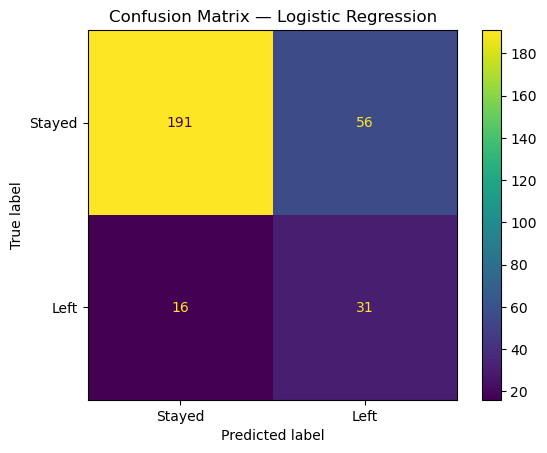


Support Vector Machine
[[212  35]
 [ 19  28]]


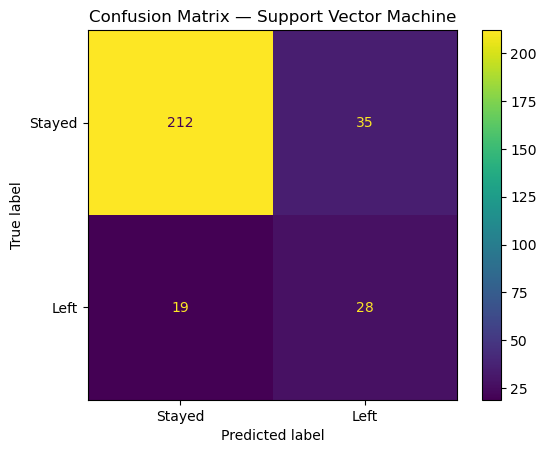


Gradient Boosting
[[240   7]
 [ 37  10]]


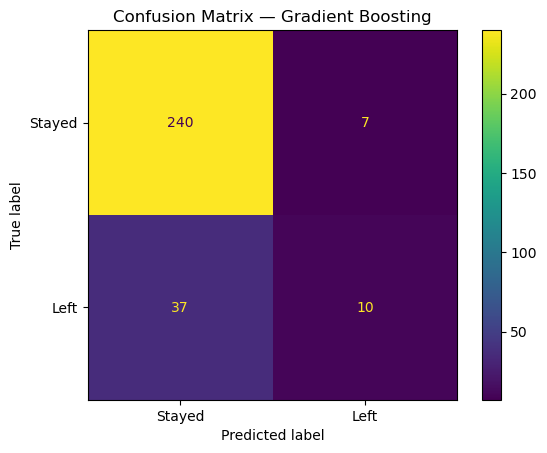

In [52]:
for name in selected_models:
    
    cm = confusion_matrix(y_test,test_predictions[name])
    
    print(f"\n{name}")
    print(cm)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["Stayed", "Left"])
    
    disp.plot()
    plt.title(f"Confusion Matrix — {name}")
    plt.show()

### 5.10. ROC Curve Comparison

Receiver Operating Characteristic (ROC) curves illustrate the ability of each model to distinguish between employees who stayed and employees who left across different classification thresholds.

The Area Under the Curve (ROC-AUC) provides a summary measure of discriminatory performance. A higher ROC-AUC indicates stronger ability to distinguish between the two classes.

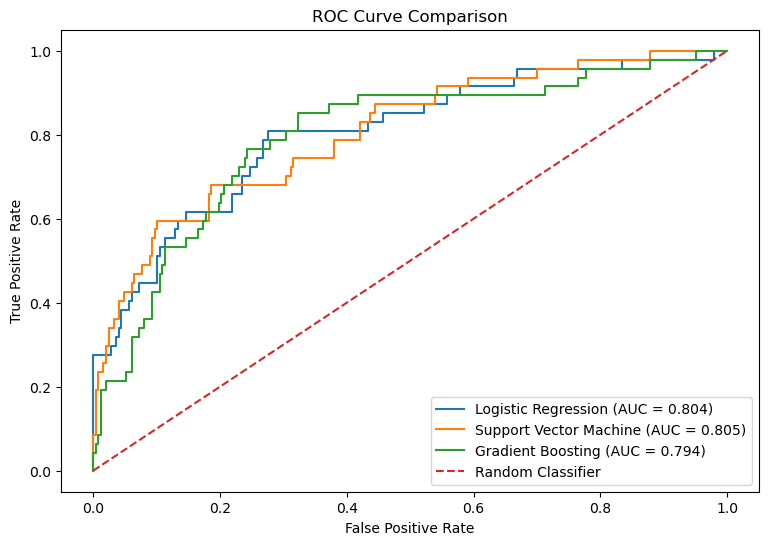

In [53]:
plt.figure(figsize=(9, 6))

for name in selected_models:
    
    y_score = test_scores[name]
    
    fpr, tpr, _ = roc_curve(y_test,y_score)
    
    auc_score = roc_auc_score(y_test,y_score)
    
    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc_score:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [54]:
# Creating the final test-performance ranking

final_comparison = evaluation_df.copy()

final_comparison = final_comparison.sort_values(
    by=["F1-Score", "ROC-AUC", "Recall"],
    ascending=False
).reset_index(drop=True)

final_comparison.index = final_comparison.index + 1

final_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
1,Support Vector Machine,0.8163,0.4444,0.5957,0.5091,0.8054
2,Logistic Regression,0.7551,0.3563,0.6596,0.4627,0.8035
3,Gradient Boosting,0.8503,0.5882,0.2128,0.3125,0.7941


### 5.11. Final Model Selection

Based on evaluation on the previously unseen test dataset, Support Vector Machine achieved the highest F1-score (0.5091) and ROC-AUC (0.8054) among the three candidate models.

Logistic Regression achieved the highest Recall for the attrition class (0.6596), correctly identifying 31 of the 47 employees who actually left. However, it generated more false positives than the Support Vector Machine.

Gradient Boosting achieved the highest Accuracy (0.8503) and Precision (0.5882), but its Recall for the attrition class was substantially lower (0.2128), meaning that it failed to identify most employees who actually left.

Considering the need to balance the identification of at-risk employees with the overall quality of predictions, the Support Vector Machine is selected as the final model. However, Logistic Regression remains a useful alternative where the primary business priority is maximising the detection of potential employee attrition.

In [55]:
final_model_name = "Support Vector Machine"
final_model = selected_models[final_model_name]

print("Final Model:", final_model_name)

Final Model: Support Vector Machine


### 5.12. Feature Importance Using Permutation Importance

Permutation importance is used to identify features that contribute most to the predictive performance of the final Support Vector Machine model.

The method measures the reduction in model performance when the values of a feature are randomly shuffled while the other features remain unchanged.

A larger decrease in performance indicates that the feature was more important to the model's predictions. Permutation importance is calculated on the held-out test dataset to provide an interpretation of the final model's behaviour.

In [56]:
perm_result = permutation_importance(
    final_model,
    X_test_processed,
    y_test,
    scoring="f1",
    n_repeats=10,
    random_state=42
)

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance Mean": perm_result.importances_mean,
    "Importance Std": perm_result.importances_std
})

feature_importance = feature_importance.sort_values(
    "Importance Mean",
    ascending=False
)

feature_importance.head(15).round(4)

,Feature,Importance Mean,Importance Std
43,cat__OverTime_Yes,0.1223,0.0218
11,num__NumCompaniesWorked,0.0353,0.0202
15,num__StockOptionLevel,0.0285,0.0327
21,num__YearsSinceLastPromotion,0.0225,0.0174
2,num__DistanceFromHome,0.0200,0.0225
5,num__HourlyRate,0.0174,0.0092
16,num__TotalWorkingYears,0.0110,0.0367
4,num__EnvironmentSatisfaction,0.0096,0.0105
18,num__WorkLifeBalance,0.0092,0.0190
8,num__JobSatisfaction,0.0084,0.0205


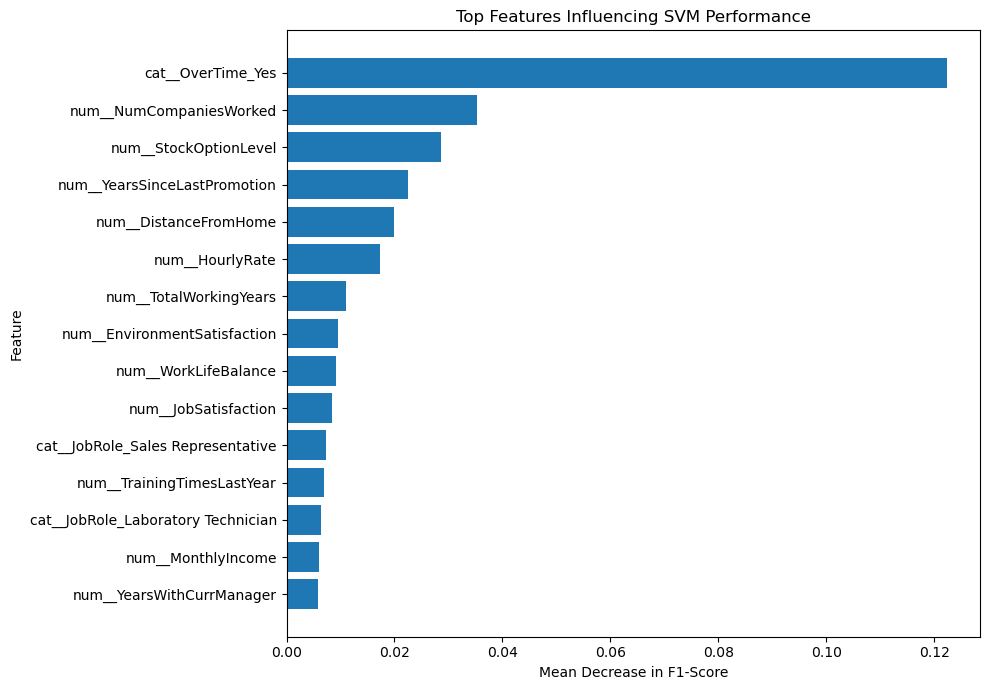

In [57]:
top_features = (
    feature_importance
    .head(15)
    .sort_values("Importance Mean")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance Mean"]
)

plt.xlabel("Mean Decrease in F1-Score")
plt.ylabel("Feature")
plt.title("Top Features Influencing SVM Performance")

plt.tight_layout()
plt.show()

### 5.13. Feature Importance Findings

Permutation importance identified the features that contributed most strongly to the Support Vector Machine's predictive performance.

**OverTime** emerged as the most influential feature by a substantial margin, indicating that overtime status plays an important role in the model's ability to distinguish between employees who are likely to leave and those who are likely to stay.

Other relatively influential features included Number of Companies Worked, Stock Option Level, Years Since Last Promotion, Distance From Home, Hourly Rate, Total Working Years, Environment Satisfaction, Work-Life Balance, and Job Satisfaction.

The results suggest that employee attrition is influenced by a combination of workload, career history, compensation-related factors, job satisfaction, and workplace conditions.

These findings should be interpreted as predictive associations rather than evidence of direct causation. Feature importance indicates which variables contribute to the model's predictions; it does not establish that changing a particular variable will necessarily cause an employee to leave or remain.

### 5.14. Key Model Evaluation Findings

Evaluation on the previously unseen test dataset produced several important findings.

**The Support Vector Machine** achieved the strongest overall balance among the evaluated models, with an F1-score of 0.5091 and ROC-AUC of 0.8054. It achieved an Accuracy of 81.63%, Precision of 44.44%, and Recall of 59.57%.

**Logistic Regression** achieved the highest Recall for the attrition class at 65.96%, correctly identifying 31 of the 47 employees who actually left. However, it produced more false positives and had a lower F1-score of 0.4627.

**Gradient Boosting** achieved the highest Accuracy (85.03%) and Precision (58.82%), but its Recall was only 21.28%. This means that although it made fewer false-positive predictions, it failed to identify most employees who actually left.

Considering the project's objective of identifying employees who may be at risk of leaving, Accuracy alone is insufficient for selecting the final model. The Support Vector Machine provided the strongest balance between Precision, Recall, F1-score and ROC-AUC and was therefore selected as the final model.

The feature-importance analysis further identified OverTime as the strongest contributor to the final model's predictive performance, followed by factors including Number of Companies Worked, Stock Option Level, Years Since Last Promotion, Distance From Home, Total Working Years, Environment Satisfaction, Work-Life Balance and Job Satisfaction.

### 5.15. Conclusion

The evaluation demonstrates that the selected models can identify patterns associated with employee attrition, although there is a clear trade-off between detecting potential leavers and minimising false-positive predictions.

The Support Vector Machine was selected as the final model because it provided the strongest overall balance of predictive performance on unseen data, achieving an F1-score of 0.5091 and ROC-AUC of 0.8054.

However, Logistic Regression demonstrated higher Recall and may be useful in situations where the organisation places greater emphasis on identifying as many potential leavers as possible, even at the cost of generating more false alarms.

The feature-importance analysis indicates that overtime, career history, compensation-related factors, job satisfaction and workplace conditions are among the most important factors contributing to the model's predictions.

These findings provide the basis for developing targeted employee-retention recommendations in Phase 6.